# DentalVision - Model Training

This notebook trains an EfficientNetB0 model to classify dental diseases from cropped dental X-ray images.

In [1]:
import os
import random
import pathlib
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.utils.class_weight import compute_class_weight

from tensorflow.keras import layers, models
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint,
    ReduceLROnPlateau
)

In [2]:
print("TensorFlow Version:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

TensorFlow Version: 2.21.0
GPU: []


In [3]:
SEED = 42

tf.random.set_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

In [4]:
DATASET_PATH = pathlib.Path(r"D:\FYP\dental-vision\ML\data\processed")

TRAIN_PATH = DATASET_PATH / "train"
VALID_PATH = DATASET_PATH / "valid"
TEST_PATH = DATASET_PATH / "test"

MODEL_PATH = pathlib.Path(r"D:\FYP\dental-vision\ML\models")
MODEL_PATH.mkdir(exist_ok=True)

In [5]:
IMAGE_SIZE = (224, 224)

BATCH_SIZE = 32

EPOCHS = 80

In [6]:
train_dataset = tf.keras.utils.image_dataset_from_directory(
    TRAIN_PATH,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    seed=SEED
)

valid_dataset = tf.keras.utils.image_dataset_from_directory(
    VALID_PATH,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_dataset = tf.keras.utils.image_dataset_from_directory(
    TEST_PATH,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

Found 35374 files belonging to 5 classes.
Found 7550 files belonging to 5 classes.
Found 7704 files belonging to 5 classes.


In [7]:
class_names = train_dataset.class_names

print("Classes:")
print(class_names)

Classes:
['Bone_Loss', 'Caries', 'Impacted_Tooth', 'Missing_Teeth', 'Periapical_Lesion']


In [8]:
AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.prefetch(AUTOTUNE)
valid_dataset = valid_dataset.prefetch(AUTOTUNE)
test_dataset = test_dataset.prefetch(AUTOTUNE)

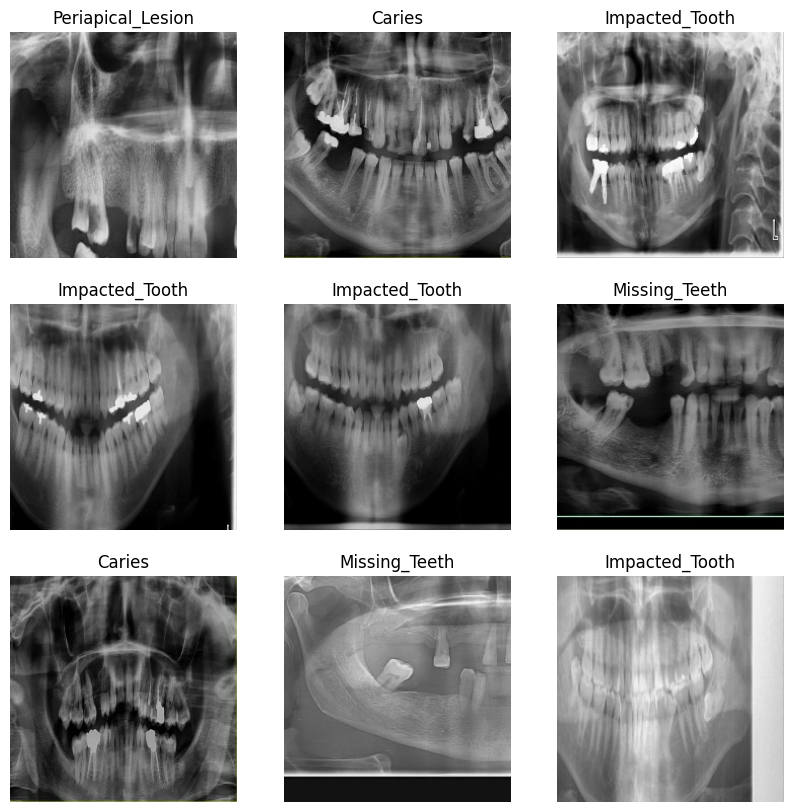

In [9]:
plt.figure(figsize=(10,10))

for images, labels in train_dataset.take(1):

    for i in range(9):

        ax = plt.subplot(3,3,i+1)

        plt.imshow(images[i].numpy().astype("uint8"))

        plt.title(class_names[labels[i]])

        plt.axis("off")

plt.show()

In [10]:
data_augmentation = tf.keras.Sequential([
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.15)
])

In [11]:
labels = []

for _, y in train_dataset:
    labels.extend(y.numpy())

labels = np.array(labels)

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(labels),
    y=labels
)

class_weights = dict(enumerate(class_weights))

print(class_weights)

{0: np.float64(3.242346471127406), 1: np.float64(0.9581256771397616), 2: np.float64(0.35776485461441215), 3: np.float64(3.0234188034188034), 4: np.float64(1.9157324668291362)}


In [12]:
base_model = EfficientNetB0(
    weights=None,
    include_top=False,
    input_shape=(224, 224, 3)
)
base_model.trainable = True

In [13]:
inputs = tf.keras.Input(shape=(224, 224, 3))

x = data_augmentation(inputs)

x = tf.keras.applications.efficientnet.preprocess_input(x)

x = base_model(x, training=True)

x = layers.GlobalAveragePooling2D()(x)

x = layers.Dropout(0.3)(x)

outputs = layers.Dense(
    len(class_names),
    activation="softmax"
)(x)

model = tf.keras.Model(inputs, outputs)

In [14]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 5)              │         6,405 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,055,976 (15.47 MB)

 Trainable params: 4,013,953 (15.31 MB)

 Non-trainable params: 42,023 (164.16 KB)

In [15]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [16]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=12,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    MODEL_PATH / "best_model.keras",
    monitor="val_accuracy",
    mode="max",
    save_best_only=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=3,
    min_lr=1e-6
)

In [17]:
history = model.fit(
    train_dataset,
    validation_data=valid_dataset,
    epochs=EPOCHS,
    class_weight=class_weights,
    callbacks=[
        early_stop,
        checkpoint,
        reduce_lr 
    ]
)

Epoch 1/80
1106/1106 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.4800 - loss: 1.5251
Epoch 1: val_accuracy improved from None to 0.63801, saving model to D:\FYP\dental-vision\ML\models\best_model.keras

Epoch 1: finished saving model to D:\FYP\dental-vision\ML\models\best_model.keras
1106/1106 ━━━━━━━━━━━━━━━━━━━━ 3712s 3s/step - accuracy: 0.5536 - loss: 1.3245 - val_accuracy: 0.6380 - val_loss: 0.9436 - learning_rate: 0.0010
Epoch 2/80
1106/1106 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.6264 - loss: 1.1052
Epoch 2: val_accuracy improved from 0.63801 to 0.74914, saving model to D:\FYP\dental-vision\ML\models\best_model.keras

Epoch 2: finished saving model to D:\FYP\dental-vision\ML\models\best_model.keras
1106/1106 ━━━━━━━━━━━━━━━━━━━━ 3338s 3s/step - accuracy: 0.6424 - loss: 1.0629 - val_accuracy: 0.7491 - val_loss: 0.7047 - learning_rate: 0.0010
Epoch 3/80
1106/1106 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.6695 - loss: 0.9837
Epoch 3: val_accuracy did not improve from 0.7

In [18]:
best_model = tf.keras.models.load_model(
    MODEL_PATH / "best_model.keras"
)

print("Best model loaded successfully.")

Best model loaded successfully.


In [19]:
test_loss, test_accuracy = best_model.evaluate(test_dataset)

print(f"\nTest Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

241/241 ━━━━━━━━━━━━━━━━━━━━ 120s 486ms/step - accuracy: 0.8667 - loss: 0.4334

Test Loss: 0.4334
Test Accuracy: 0.8667


In [20]:
import numpy as np

predictions = best_model.predict(test_dataset)

predicted_labels = np.argmax(predictions, axis=1)

241/241 ━━━━━━━━━━━━━━━━━━━━ 110s 447ms/step


In [21]:
true_labels = np.concatenate([
    labels.numpy()
    for _, labels in test_dataset
])

In [22]:
from sklearn.metrics import classification_report

print(
    classification_report(
        true_labels,
        predicted_labels,
        target_names=class_names,
        digits=4
    )
)

                   precision    recall  f1-score   support

        Bone_Loss     0.5986    0.6667    0.6308       528
           Caries     0.8394    0.8834    0.8609      1716
   Impacted_Tooth     0.9650    0.8987    0.9307      4116
    Missing_Teeth     0.7934    0.8768    0.8330       552
Periapical_Lesion     0.7220    0.7904    0.7547       792

         accuracy                         0.8667      7704
        macro avg     0.7837    0.8232    0.8020      7704
     weighted avg     0.8747    0.8667    0.8695      7704



In [23]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(true_labels, predicted_labels)

print(cm)

[[ 352   79   39   18   40]
 [  45 1516   43   75   37]
 [ 131  122 3699   16  148]
 [   4   45    3  484   16]
 [  56   44   49   17  626]]


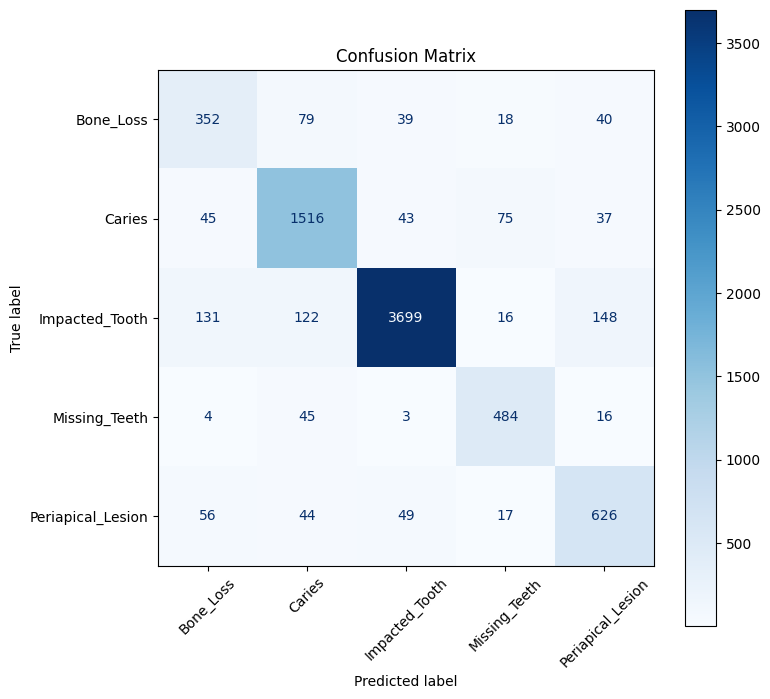

In [24]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

fig, ax = plt.subplots(figsize=(8,8))

disp.plot(
    ax=ax,
    cmap="Blues",
    xticks_rotation=45
)

plt.title("Confusion Matrix")
plt.show()

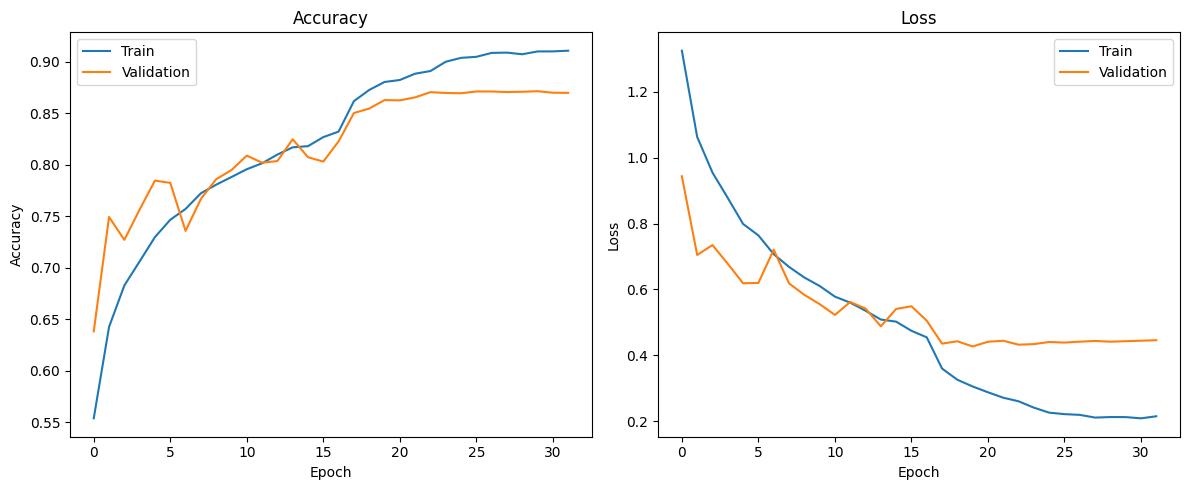

In [25]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)

plt.plot(history.history["accuracy"], label="Train")
plt.plot(history.history["val_accuracy"], label="Validation")

plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1,2,2)

plt.plot(history.history["loss"], label="Train")
plt.plot(history.history["val_loss"], label="Validation")

plt.title("Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()

plt.show()

In [26]:
import pandas as pd

history_df = pd.DataFrame(history.history)

history_df.to_csv(
    MODEL_PATH / "training_history.csv",
    index=False
)

print("Training history saved.")

Training history saved.


In [27]:
# Phase 2: continue training the whole network at a lower learning rate.
# (Freezing early layers doesn't apply here -- nothing was pretrained,
# so there are no "general features" worth protecting from update.
# All layers stay trainable; only the learning rate drops.)
base_model.trainable = True

In [28]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [29]:
# Separate checkpoint for the fine-tuning phase so it doesn't silently
# depend on a file ("fine_tuned_model.keras") that nothing ever saves.
checkpoint_finetune = ModelCheckpoint(
    MODEL_PATH / "fine_tuned_model.keras",
    monitor="val_accuracy",
    mode="max",
    save_best_only=True,
    verbose=1
)

In [30]:
history_finetune = model.fit(
    train_dataset,
    validation_data=valid_dataset,
    epochs=10,
    class_weight=class_weights,
    callbacks=[
        early_stop,
        checkpoint_finetune,
        reduce_lr
    ]
)

Epoch 1/10
1106/1106 ━━━━━━━━━━━━━━━━━━━━ 0s 18s/step - accuracy: 0.8899 - loss: 0.2962 
Epoch 1: val_accuracy improved from None to 0.86119, saving model to D:\FYP\dental-vision\ML\models\fine_tuned_model.keras

Epoch 1: finished saving model to D:\FYP\dental-vision\ML\models\fine_tuned_model.keras
1106/1106 ━━━━━━━━━━━━━━━━━━━━ 20442s 18s/step - accuracy: 0.8907 - loss: 0.2800 - val_accuracy: 0.8612 - val_loss: 0.4303 - learning_rate: 1.0000e-05
Epoch 2/10
1106/1106 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8851 - loss: 0.2932
Epoch 2: val_accuracy improved from 0.86119 to 0.86252, saving model to D:\FYP\dental-vision\ML\models\fine_tuned_model.keras

Epoch 2: finished saving model to D:\FYP\dental-vision\ML\models\fine_tuned_model.keras
1106/1106 ━━━━━━━━━━━━━━━━━━━━ 3386s 3s/step - accuracy: 0.8878 - loss: 0.2757 - val_accuracy: 0.8625 - val_loss: 0.4322 - learning_rate: 1.0000e-05
Epoch 3/10
1106/1106 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8899 - loss: 0.2753
Epoch 3: v

In [31]:
best_model = tf.keras.models.load_model(
    MODEL_PATH / "fine_tuned_model.keras"
)

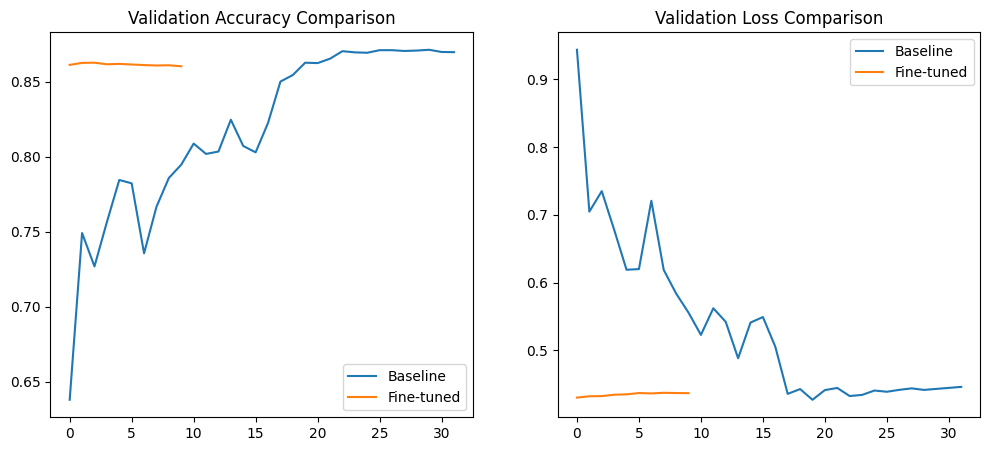

In [32]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history["val_accuracy"], label="Baseline")
plt.plot(history_finetune.history["val_accuracy"], label="Fine-tuned")
plt.title("Validation Accuracy Comparison")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history["val_loss"], label="Baseline")
plt.plot(history_finetune.history["val_loss"], label="Fine-tuned")
plt.title("Validation Loss Comparison")
plt.legend()

plt.show()

In [33]:
best_model = tf.keras.models.load_model(
    MODEL_PATH / "fine_tuned_model.keras"
)

print("Fine-tuned model loaded successfully!")

Fine-tuned model loaded successfully!


In [34]:
test_loss, test_accuracy = best_model.evaluate(test_dataset)

print(f"\nTest Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

241/241 ━━━━━━━━━━━━━━━━━━━━ 147s 595ms/step - accuracy: 0.8605 - loss: 0.4286

Test Loss: 0.4286
Test Accuracy: 0.8605


In [35]:
predictions = best_model.predict(test_dataset)

predicted_labels = np.argmax(predictions, axis=1)

241/241 ━━━━━━━━━━━━━━━━━━━━ 134s 550ms/step


In [36]:
from sklearn.metrics import classification_report

print(classification_report(
    true_labels,
    predicted_labels,
    target_names=class_names,
    digits=4
))

                   precision    recall  f1-score   support

        Bone_Loss     0.5882    0.6818    0.6316       528
           Caries     0.8413    0.8555    0.8483      1716
   Impacted_Tooth     0.9670    0.8975    0.9309      4116
    Missing_Teeth     0.7515    0.8822    0.8117       552
Periapical_Lesion     0.7053    0.7828    0.7421       792

         accuracy                         0.8605      7704
        macro avg     0.7707    0.8200    0.7929      7704
     weighted avg     0.8707    0.8605    0.8641      7704



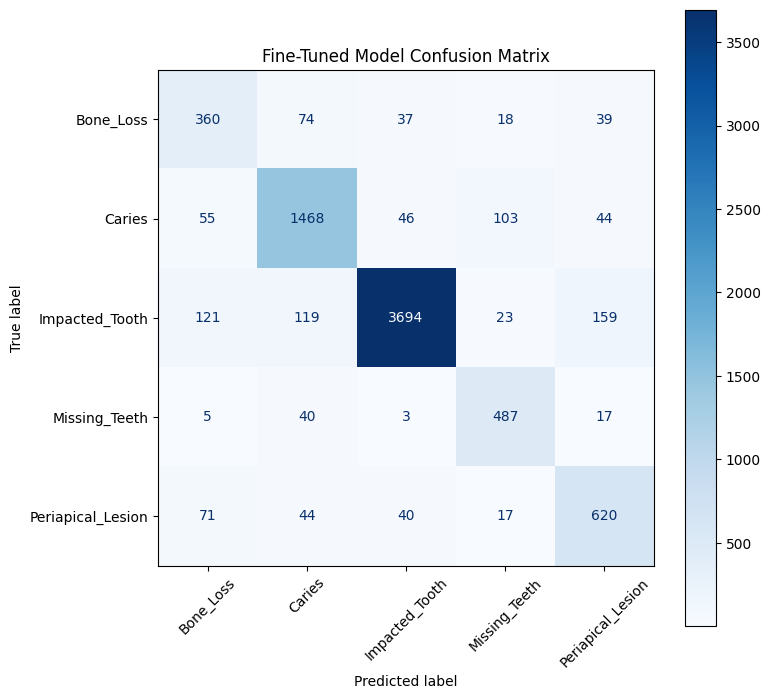

In [37]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(true_labels, predicted_labels)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

fig, ax = plt.subplots(figsize=(8, 8))
disp.plot(ax=ax, cmap="Blues", xticks_rotation=45)
plt.title("Fine-Tuned Model Confusion Matrix")
plt.show()

In [38]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
import pandas as pd

accuracy = accuracy_score(true_labels, predicted_labels)
precision, recall, f1, _ = precision_recall_fscore_support(
    true_labels,
    predicted_labels,
    average="weighted"
)

results = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-Score"],
    "Value": [accuracy, precision, recall, f1]
})

print(results)

results.to_csv(MODEL_PATH / "evaluation_results.csv", index=False)

print("\nEvaluation results saved successfully!")

      Metric     Value
0   Accuracy  0.860462
1  Precision  0.870705
2     Recall  0.860462
3   F1-Score  0.864059

Evaluation results saved successfully!
